In [3]:
# Loading the dataset

import sys
sys.path.append("..")

from datasets import load_dataset   
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset = load_dataset("stanfordnlp/sst2")
print(dataset)

README.md:   0%|          | 0.00/5.27k [00:00<?, ?B/s]

c:\Users\91702\Desktop\BoyWithNuke\sentiment-clf\venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\91702\.cache\huggingface\hub\datasets--stanfordnlp--sst2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 872
    })
    test: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 1821
    })
})


In [7]:
# Converting to data frame

train_df = dataset['train'].to_pandas()
val_df = dataset['validation'].to_pandas()

print("=== TRAIN SAMPLE ===")
print(train_df.head(10))
print(f"\nShape: {train_df.shape}")
print(f"\nColumns: {train_df.columns.to_list()}")
print(f"\nLabel values: {train_df['label'].unique()}")
print(f"\nNull values:\n{train_df.isnull().sum()}")

=== TRAIN SAMPLE ===
   idx                                           sentence  label
0    0       hide new secretions from the parental units       0
1    1               contains no wit , only labored gags       0
2    2  that loves its characters and communicates som...      1
3    3  remains utterly satisfied to remain the same t...      0
4    4  on the worst revenge-of-the-nerds clichés the ...      0
5    5  that 's far too tragic to merit such superfici...      0
6    6  demonstrates that the director of such hollywo...      1
7    7                                          of saucy       1
8    8   a depressed fifteen-year-old 's suicidal poetry       0
9    9  are more deeply thought through than in most `...      1

Shape: (67349, 3)

Columns: ['idx', 'sentence', 'label']

Label values: [0 1]

Null values:
idx         0
sentence    0
label       0
dtype: int64


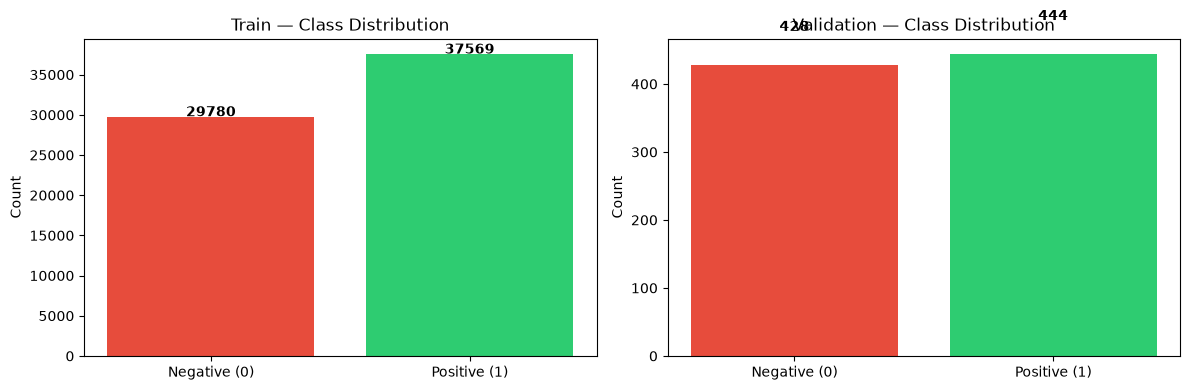


Train class balance: {1: 0.5578256544269403, 0: 0.44217434557305973}


In [9]:
# Class distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, df) in zip(axes, [("Train", train_df), ("Validation", val_df)]):
    counts = df["label"].value_counts().sort_index()
    ax.bar(["Negative (0)", "Positive (1)"], counts.values, color=["#e74c3c", "#2ecc71"])
    ax.set_title(f"{name} — Class Distribution")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 50, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../data/processed/class_distribution.png", dpi=150)
plt.show()

print(f"\nTrain class balance: {train_df['label'].value_counts(normalize=True).to_dict()}")

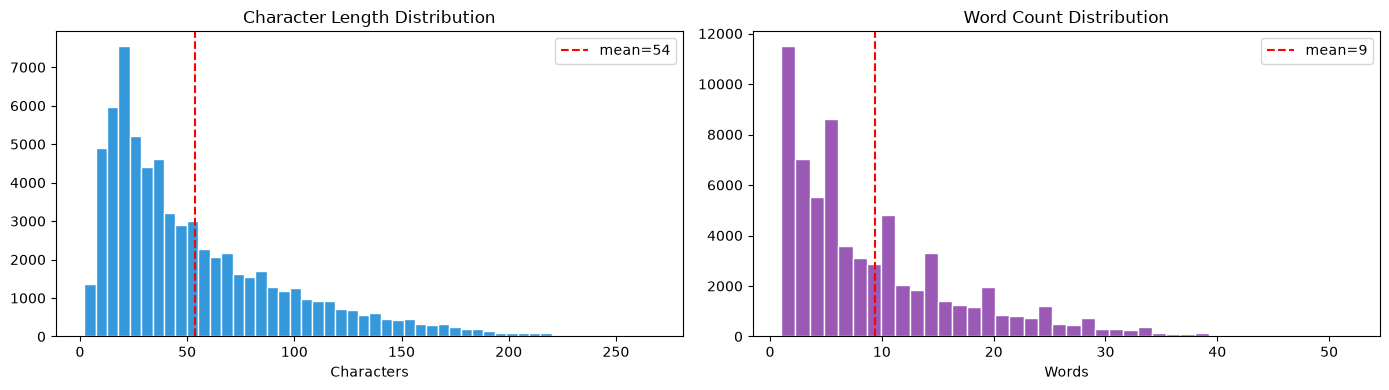

       text_length    word_count
count  67349.00000  67349.000000
mean      53.50559      9.409553
std       43.40738      8.073806
min        2.00000      1.000000
25%       21.00000      3.000000
50%       39.00000      7.000000
75%       74.00000     13.000000
max      268.00000     52.000000


In [10]:
# Text Length Distribution

train_df["text_length"] = train_df["sentence"].str.len()
train_df["word_count"]  = train_df["sentence"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train_df["text_length"], bins=50, color="#3498db", edgecolor="white")
axes[0].set_title("Character Length Distribution")
axes[0].set_xlabel("Characters")
axes[0].axvline(train_df["text_length"].mean(), color="red", linestyle="--", label=f'mean={train_df["text_length"].mean():.0f}')
axes[0].legend()

axes[1].hist(train_df["word_count"], bins=40, color="#9b59b6", edgecolor="white")
axes[1].set_title("Word Count Distribution")
axes[1].set_xlabel("Words")
axes[1].axvline(train_df["word_count"].mean(), color="red", linestyle="--", label=f'mean={train_df["word_count"].mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/processed/length_distribution.png", dpi=150)
plt.show()

print(train_df[["text_length", "word_count"]].describe())

In [12]:
# Seeing Data Examples

print("=== NEGATIVE EXAMPLES (label=0) ===")
for row in train_df[train_df["label"] == 0].sample(5, random_state=42)["sentence"]:
    print(f"  • {row}")

print("\n=== POSITIVE EXAMPLES (label=1) ===")
for row in train_df[train_df["label"] == 1].sample(5, random_state=42)["sentence"]:
    print(f"  • {row}")

print("\n=== SHORTEST EXAMPLES ===")
print(train_df.nsmallest(5, "word_count")[["sentence", "label", "word_count"]])

print("\n=== LONGEST EXAMPLES ===")
print(train_df.nlargest(5, "word_count")[["sentence", "label", "word_count"]])

=== NEGATIVE EXAMPLES (label=0) ===
  • a dull , dumb and derivative horror 
  • if george romero had directed this movie , it would n't have taken the protagonists a full hour to determine that in order to kill a zombie you must shoot it in the head 
  • the acting is amateurish , the cinematography is atrocious 
  • maudlin ending 
  • derailed 

=== POSITIVE EXAMPLES (label=1) ===
  • acted meditation on both the profoundly devastating events of one year ago and the slow , painful healing process that has followed in their wake 
  • this odd , poetic road movie , spiked by jolts of pop music , pretty much takes place in morton 's ever-watchful gaze -- and it 's a tribute to the actress , and to her inventive director , that the journey is such a mesmerizing one . 
  • directed with purpose and finesse by england 's roger mitchell , who handily makes the move from pleasing , relatively lightweight commercial fare such as notting hill to commercial fare with real thematic heft . 
  • 

In [13]:
# Saving dataset in the data folder

import os
os.makedirs("../data/raw", exist_ok=True)

train_df[["sentence", "label"]].to_csv("../data/raw/train.csv", index=False)
val_df[["sentence", "label"]].to_csv("../data/raw/val.csv", index=False)

print("Saved to data/raw/")
print(f"  train.csv → {len(train_df)} rows")
print(f"  val.csv   → {len(val_df)} rows")

Saved to data/raw/
  train.csv → 67349 rows
  val.csv   → 872 rows
